# Network Geographic Decentralization: Exploratory Data Analysis

This notebook provides complete transparency into how we measure geographic decentralization across blockchain networks. You'll see the full journey from raw data to the scores displayed on [geobeat.xyz](https://geobeat.xyz).

## The Transparency Chain

```
Raw CSV Data → This Notebook → Production Scripts → gdi_results.json → Website
     ↓              ↓                   ↓                    ↓              ↓
  data/raw/   Exploration &    src/analysis/*.py   Consumed by   geobeat.xyz
              Methodology                          Frontend
```

## What You'll Find Here

1. **Data Overview** - What we collected and from where
2. **Geographic Visualizations** - Interactive world maps showing node distribution
3. **Concentration Analysis** - Charts revealing where power clusters
4. **Network Comparisons** - Side-by-side analysis of Ethereum, Polygon, and Filecoin
5. **Methodology Demonstration** - Step-by-step GDI calculation
6. **Production Bridge** - How this analysis becomes live code

---

In [1]:
# Core imports
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import json

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Spatial analysis
import h3
from scipy.spatial import cKDTree
from shapely.geometry import Point

# Configuration
pd.options.display.max_rows = 100
pd.options.display.max_columns = None

# Color palette (colorblind-friendly)
COLORS = {
    'ethereum': '#627EEA',  # Blue
    'polygon': '#8247E5',   # Purple
    'filecoin': '#0090FF',  # Bright blue
    'celo': '#FCFF52'       # Yellow
}

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


## 1. Data Overview

We collected node location data from blockchain network crawlers for three major networks:
- **Ethereum** (Layer 1)
- **Polygon** (Layer 2)
- **Filecoin** (Storage network)

### Data Collection

Each node's IP address was enriched with:
- Geographic location (country, city, lat/lon) via IP geolocation
- Hosting provider / organization
- Autonomous System (AS) information
- Infrastructure type (cloud, mobile, proxy detection)

### Data Quality Notes

**Strengths:**
- Large sample sizes (thousands of nodes per network)
- Rich metadata including hosting providers and ASN data
- Geographic coordinates enable spatial analysis

**Limitations:**
- IP geolocation has variable accuracy (typically city-level)
- VPNs and proxies can mask true locations
- Measures hardware location, not operator jurisdiction
- Organization names require normalization

See our [Methodology](../../docs/METHODOLOGY.md) for details on limitations and future work.

In [18]:
# Load network data
DATA_DIR = Path('../raw')

networks = {
    'ethereum': pd.read_csv(DATA_DIR / '2025-11-22-ethereum-ips.csv'),
    'polygon': pd.read_csv(DATA_DIR / '2025-11-22-polygon-ips.csv'),
    'filecoin': pd.read_csv(DATA_DIR / '2025-11-22-filecoin-ips.csv')
}

# Convert 't'/'f' string columns to proper booleans
for name, df in networks.items():
    for col in ['hosting', 'proxy', 'mobile']:
        if col in df.columns:
            df[col] = df[col] == 't'

def normalize_org(org_name):
    """
    Normalize organization names to consolidate cloud providers and hosting companies.
    
    This addresses data quality issues where the same entity appears under multiple names:
    - AWS regions (us-east-1, eu-west-1, etc.) → "Amazon Web Services (AWS)"
    - Hetzner variants → "Hetzner"
    - Google variants → "Google Cloud"
    - etc.
    """
    if pd.isna(org_name):
        return org_name
    
    org_lower = org_name.lower()
    
    # Amazon/AWS consolidation
    if any(x in org_lower for x in ['amazon', 'aws', 'ec2']):
        return 'Amazon Web Services (AWS)'
    
    # Google consolidation
    if any(x in org_lower for x in ['google', 'gcp', 'cloud platform']):
        return 'Google Cloud'
    
    # Microsoft/Azure consolidation
    if any(x in org_lower for x in ['microsoft', 'azure']):
        return 'Microsoft Azure'
    
    # Hetzner consolidation
    if 'hetzner' in org_lower:
        return 'Hetzner'

    if 'tencent' in org_lower:
        return 'Tencent'
    
    # OVH consolidation
    if 'ovh' in org_lower:
        return 'OVH'
    
    # DigitalOcean consolidation
    if 'digitalocean' in org_lower or 'digital ocean' in org_lower:
        return 'DigitalOcean'
    
    # Linode/Akamai consolidation
    if 'linode' in org_lower or 'akamai' in org_lower:
        return 'Akamai (Linode)'
    
    # Cloudflare consolidation
    if 'cloudflare' in org_lower:
        return 'Cloudflare'
    
    # Vultr consolidation
    if 'vultr' in org_lower:
        return 'Vultr'
    
    # Contabo consolidation
    if 'contabo' in org_lower:
        return 'Contabo'
    
    # Keep original if no match
    return org_name

# Apply org normalization
for name, df in networks.items():
    df['org_normalized'] = df['org'].apply(normalize_org)
    print(f"✓ {name.title()}: Normalized {df['org'].nunique()} orgs → {df['org_normalized'].nunique()} unique entities")

# Summary statistics table
summary_data = []
for name, df in networks.items():
    summary_data.append({
        'Network': name.title(),
        'Total Nodes': f"{len(df):,}",
        'Countries': df['country'].nunique(),
        'Cities': df['city'].nunique(),
        'Organizations': df['org'].nunique(),
        'Orgs (normalized)': df['org_normalized'].nunique(),
        'ASNs': df['asname'].nunique(),
        'Hosted (%)': f"{(df['hosting'].sum() / len(df) * 100):.1f}%",
        'Data Date': '2025-11-22'
    })

summary_df = pd.DataFrame(summary_data)
summary_df

✓ Ethereum: Normalized 2274 orgs → 2184 unique entities
✓ Polygon: Normalized 1346 orgs → 1252 unique entities
✓ Filecoin: Normalized 116 orgs → 108 unique entities


,Network,Total Nodes,Countries,Cities,Organizations,Orgs (normalized),ASNs,Hosted (%),Data Date
0,Ethereum,"17,356",103,2524,2274,2184,1416,56.1%,2025-11-22
1,Polygon,"11,242",82,1236,1346,1252,885,67.8%,2025-11-22
2,Filecoin,256,25,117,116,108,92,20.3%,2025-11-22


In [19]:
# Summary statistics table
summary_data = []
for name, df in networks.items():
    summary_data.append({
        'Network': name.title(),
        'Total Nodes': f"{len(df):,}",
        'Countries': df['country'].nunique(),
        'Cities': df['city'].nunique(),
        'Organizations': df['org'].nunique(),
        'ASNs': df['asname'].nunique(),
        'Hosted (%)': f"{(df['hosting'].sum() / len(df) * 100):.1f}%",
        'Data Date': '2025-11-22'
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Network,Total Nodes,Countries,Cities,Organizations,ASNs,Hosted (%),Data Date
0,Ethereum,"17,356",103,2524,2274,1416,56.1%,2025-11-22
1,Polygon,"11,242",82,1236,1346,885,67.8%,2025-11-22
2,Filecoin,256,25,117,116,92,20.3%,2025-11-22


### Organization Normalization

A key data quality challenge: the same hosting provider appears under multiple names in the raw data. For example:
- AWS regions: "AWS EC2 (us-east-1)", "AWS EC2 (eu-west-1)", "Amazon.com Inc.", etc.
- Hetzner: "Hetzner", "Hetzner Online GmbH", "Hetzner Online AG", etc.

We normalize these to accurately measure concentration. Here are some examples of the consolidation:

In [20]:
# Show sample rows from each dataset
print("Sample data from Ethereum:")
networks['ethereum'].head(3)

Sample data from Ethereum:


,ip,country,country_code,city,region_name,lat,lon,isp,org,as_raw,asname,hosting,proxy,mobile,org_normalized
0,109.111.106.105,Andorra,AD,Andorra la Vella,Andorra la Vella,42.5055,1.5243,"ANDORRA TELECOM, S.A.U.","ANDORRA TELECOM, S.A.U",AS6752 Andorra Telecom,ANDORRA,False,False,False,"ANDORRA TELECOM, S.A.U"
1,46.172.237.128,Andorra,AD,Andorra la Vella,Andorra la Vella,42.5055,1.5243,"ANDORRA TELECOM, S.A.U.","ANDORRA TELECOM, S.A.U",AS6752 Andorra Telecom,ANDORRA,False,False,False,"ANDORRA TELECOM, S.A.U"
2,185.132.201.163,Andorra,AD,Santa Coloma,Andorra la Vella,42.5014,1.4985,Andorra Telecom SAU,Bitcanal UK,AS6752 Andorra Telecom,ANDORRA,False,False,False,Bitcanal UK


## 2. Geographic Visualization

Let's visualize where nodes are physically located around the world. These interactive maps reveal concentration patterns that aren't obvious from summary statistics alone.

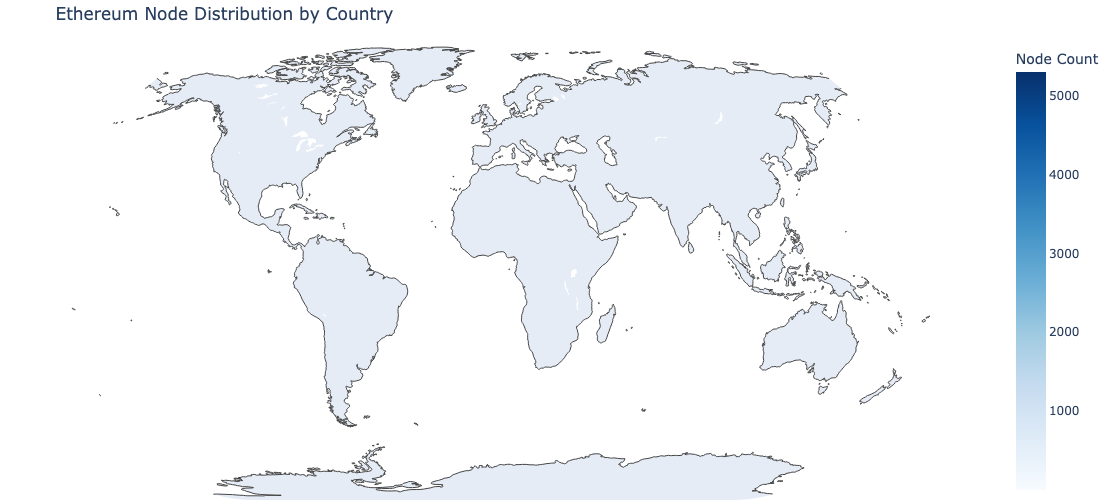

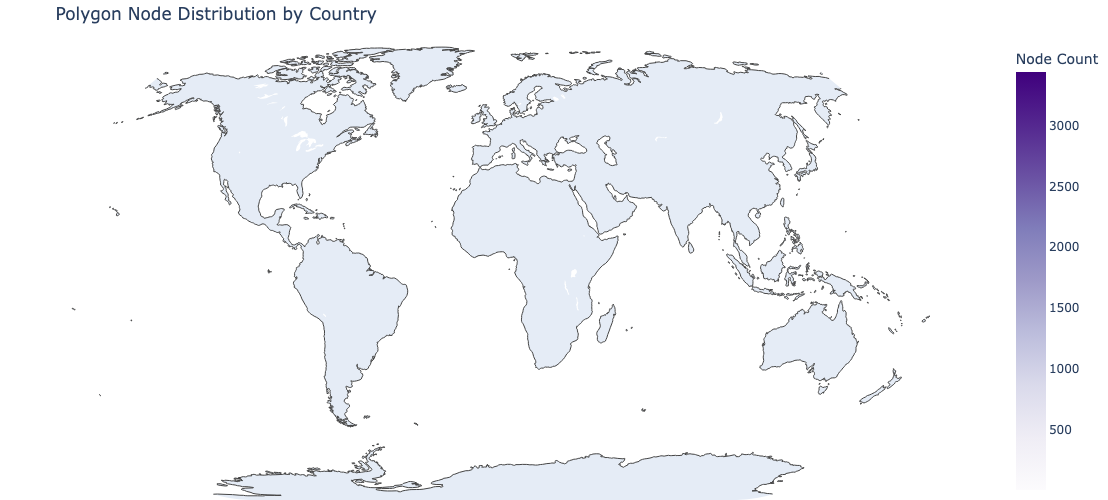

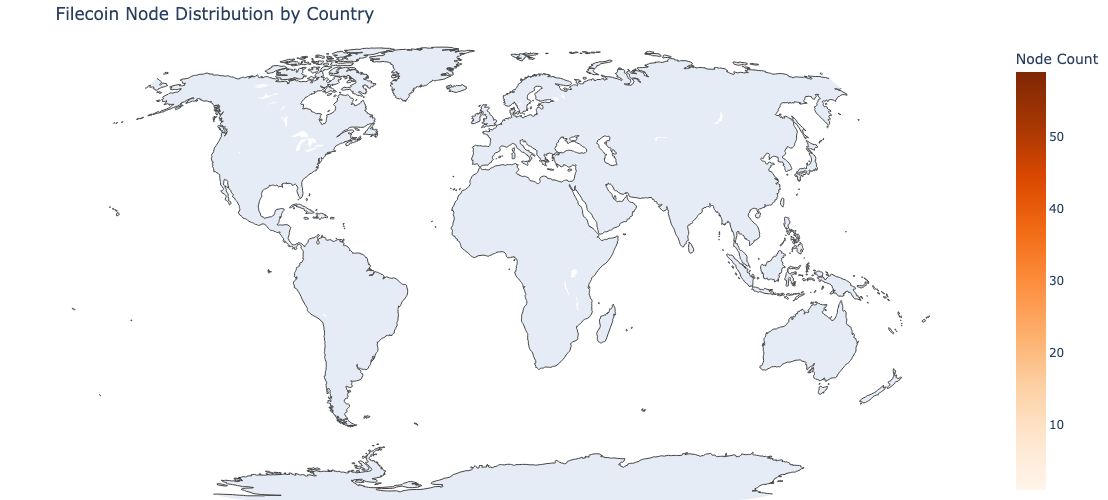

In [21]:
def create_world_map(df, network_name, title=None):
    """Create an interactive choropleth map showing node distribution by country."""
    country_counts = df['country'].value_counts().reset_index()
    country_counts.columns = ['country', 'node_count']
    
    # Add ISO codes for mapping
    country_iso = df[['country', 'country_code']].drop_duplicates()
    country_counts = country_counts.merge(country_iso, on='country', how='left')
    
    fig = px.choropleth(
        country_counts,
        locations='country_code',
        color='node_count',
        hover_name='country',
        hover_data={'country_code': False, 'node_count': ':,'},
        color_continuous_scale='Blues' if network_name == 'ethereum' else 'Purples' if network_name == 'polygon' else 'Oranges',
        title=title or f'{network_name.title()} Node Distribution by Country',
        labels={'node_count': 'Node Count'}
    )
    
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=500,
        margin={"r":0,"t":40,"l":0,"b":0}
    )
    
    return fig

# Create maps for each network
for name, df in networks.items():
    fig = create_world_map(df, name)
    fig.show()

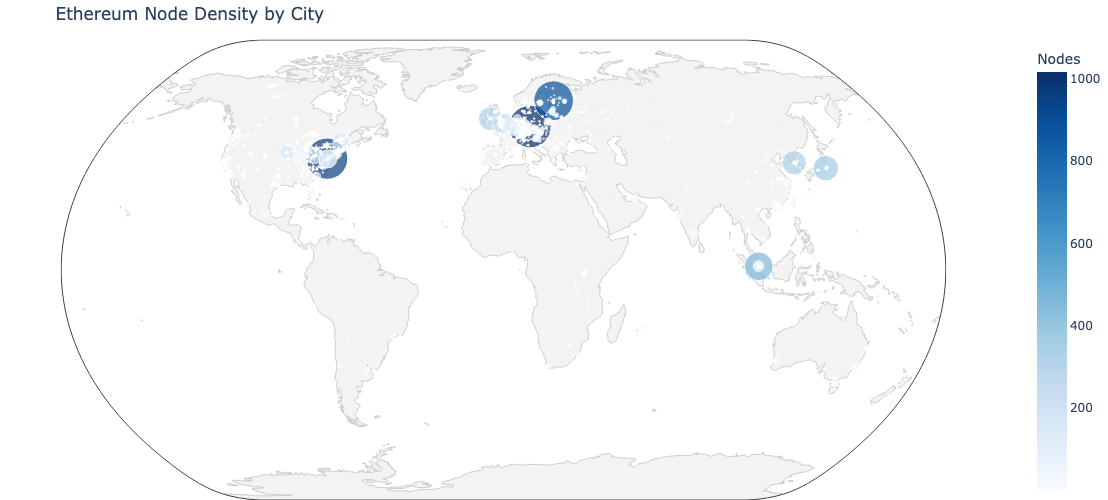

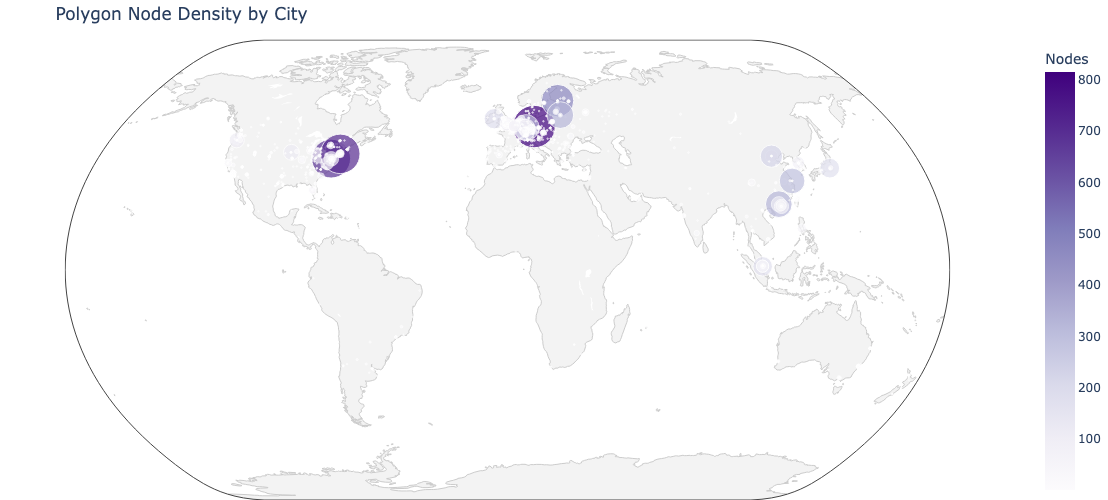

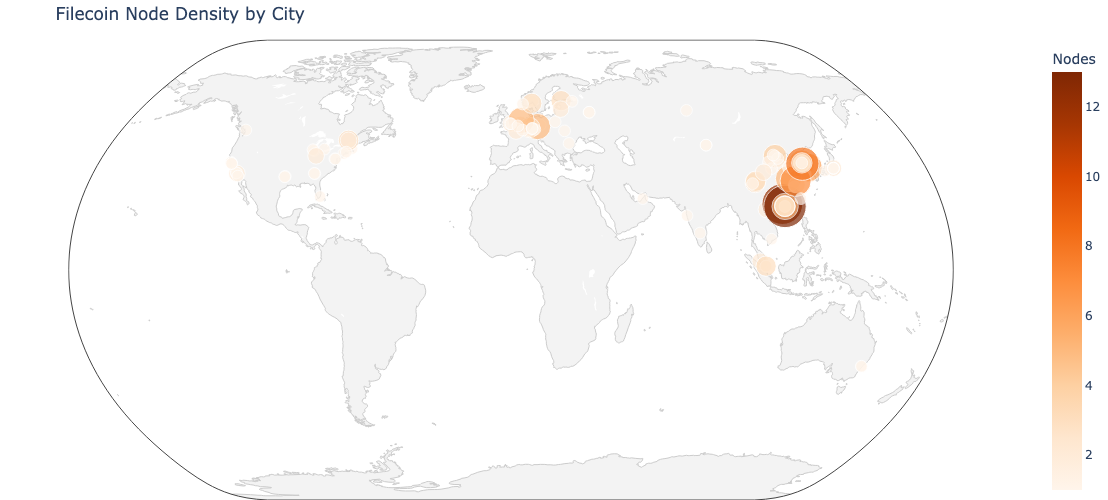

In [22]:
def create_scatter_map(df, network_name, sample_size=5000):
    """Create a scatter map with sized bubbles for node density."""
    # Sample if dataset is large
    if len(df) > sample_size:
        df_plot = df.sample(n=sample_size, random_state=42)
    else:
        df_plot = df.copy()
    
    # Group by city for bubble sizing
    city_counts = df.groupby(['city', 'country', 'lat', 'lon']).size().reset_index(name='node_count')
    
    fig = px.scatter_geo(
        city_counts,
        lat='lat',
        lon='lon',
        size='node_count',
        hover_name='city',
        hover_data={'country': True, 'node_count': ':,', 'lat': False, 'lon': False},
        color='node_count',
        color_continuous_scale='Blues' if network_name == 'ethereum' else 'Purples' if network_name == 'polygon' else 'Oranges',
        size_max=30,
        title=f'{network_name.title()} Node Density by City',
        labels={'node_count': 'Nodes'}
    )
    
    fig.update_layout(
        geo=dict(
            showland=True,
            landcolor='rgb(243, 243, 243)',
            coastlinecolor='rgb(204, 204, 204)',
            projection_type='natural earth',
            showlakes=True,
            lakecolor='rgb(255, 255, 255)'
        ),
        height=500,
        margin={"r":0,"t":40,"l":0,"b":0}
    )
    
    return fig

# Create scatter maps
for name, df in networks.items():
    fig = create_scatter_map(df, name)
    fig.show()

## 3. Concentration Analysis

Beyond visualization, we need quantitative measures of concentration. This section reveals:
- Which countries and organizations control the most nodes
- Whether concentration exceeds critical thresholds
- How different networks compare on concentration risk

In [23]:
def analyze_concentration(df, dimension='country', top_n=10):
    """Calculate concentration metrics for a given dimension."""
    counts = df[dimension].value_counts()
    total = len(df)
    shares = counts / total
    
    # Herfindahl-Hirschman Index (HHI)
    hhi = (shares ** 2).sum()
    
    # Top N concentration
    top_n_share = shares.head(top_n).sum()
    
    # Create summary
    top_entries = pd.DataFrame({
        dimension: counts.head(top_n).index,
        'count': counts.head(top_n).values,
        'share': (shares.head(top_n) * 100).round(2).values
    })
    
    return {
        'hhi': hhi,
        'num_unique': len(counts),
        'top_1_share': shares.iloc[0],
        'top_2_share': shares.head(2).sum(),
        'top_3_share': shares.head(3).sum(),
        'top_n_share': top_n_share,
        'top_entries': top_entries
    }

# Analyze country concentration for all networks
print("Country Concentration Analysis")
print("=" * 80)
for name, df in networks.items():
    stats = analyze_concentration(df, 'country', top_n=5)
    print(f"\n{name.upper()}:")
    print(f"  Total countries: {stats['num_unique']}")
    print(f"  Top 1 country: {stats['top_1_share']:.1%}")
    print(f"  Top 2 countries: {stats['top_2_share']:.1%}")
    print(f"  Top 3 countries: {stats['top_3_share']:.1%}")
    print(f"  HHI: {stats['hhi']:.3f}")
    print(f"\n  Top 5 countries:")
    for _, row in stats['top_entries'].iterrows():
        print(f"    {row['country']}: {row['count']:,} nodes ({row['share']:.1f}%)")

Country Concentration Analysis

ETHEREUM:
  Total countries: 103
  Top 1 country: 30.5%
  Top 2 countries: 44.7%
  Top 3 countries: 50.1%
  HHI: 0.129

  Top 5 countries:
    United States: 5,298 nodes (30.5%)
    Germany: 2,465 nodes (14.2%)
    Finland: 932 nodes (5.4%)
    United Kingdom: 863 nodes (5.0%)
    France: 849 nodes (4.9%)

POLYGON:
  Total countries: 82
  Top 1 country: 30.6%
  Top 2 countries: 46.8%
  Top 3 countries: 57.2%
  HHI: 0.142

  Top 5 countries:
    United States: 3,443 nodes (30.6%)
    Germany: 1,823 nodes (16.2%)
    China: 1,167 nodes (10.4%)
    Finland: 491 nodes (4.4%)
    France: 465 nodes (4.1%)

FILECOIN:
  Total countries: 25
  Top 1 country: 23.0%
  Top 2 countries: 45.3%
  Top 3 countries: 59.0%
  HHI: 0.138

  Top 5 countries:
    China: 59 nodes (23.1%)
    South Korea: 57 nodes (22.3%)
    Hong Kong: 35 nodes (13.7%)
    United States: 24 nodes (9.4%)
    Germany: 13 nodes (5.1%)


In [24]:
# Analyze organization/hosting provider concentration
print("\nOrganization/Hosting Provider Concentration (Normalized)")
print("=" * 80)
for name, df in networks.items():
    stats = analyze_concentration(df, 'org_normalized', top_n=5)
    print(f"\n{name.upper()}:")
    print(f"  Total organizations: {stats['num_unique']}")
    print(f"  Top 1 org: {stats['top_1_share']:.1%}")
    print(f"  Top 3 orgs: {stats['top_3_share']:.1%}")
    print(f"  HHI: {stats['hhi']:.3f}")
    print(f"\n  Top 5 organizations:")
    for _, row in stats['top_entries'].iterrows():
        org_name = row['org_normalized'][:50] + '...' if len(row['org_normalized']) > 50 else row['org_normalized']
        print(f"    {org_name}: {row['count']:,} nodes ({row['share']:.1f}%)")


Organization/Hosting Provider Concentration (Normalized)

ETHEREUM:
  Total organizations: 2184
  Top 1 org: 17.7%
  Top 3 orgs: 36.8%
  HHI: 0.053

  Top 5 organizations:
    Amazon Web Services (AWS): 3,070 nodes (17.7%)
    Hetzner: 1,920 nodes (11.1%)
    OVH: 1,394 nodes (8.0%)
    Google Cloud: 691 nodes (4.0%)
    Spectrum: 282 nodes (1.6%)

POLYGON:
  Total organizations: 1252
  Top 1 org: 13.8%
  Top 3 orgs: 30.3%
  HHI: 0.041

  Top 5 organizations:
    Amazon Web Services (AWS): 1,548 nodes (13.8%)
    Hetzner: 1,000 nodes (8.9%)
    Tencent: 856 nodes (7.6%)
    OVH: 727 nodes (6.5%)
    Google Cloud: 368 nodes (3.3%)

FILECOIN:
  Total organizations: 108
  Top 1 org: 6.6%
  Top 3 orgs: 18.4%
  HHI: 0.020

  Top 5 organizations:
    Chinanet GD: 17 nodes (6.6%)
    Korea Telecom: 16 nodes (6.2%)
    Kornet: 14 nodes (5.5%)
    Boranet: 9 nodes (3.5%)
    OVH: 9 nodes (3.5%)


In [25]:
# Show the impact of normalization on concentration
print("\n" + "=" * 80)
print("Impact of Organization Normalization:")
print("=" * 80)

# Show examples
eth_df = networks['ethereum']
normalization_examples = eth_df[['org', 'org_normalized']].drop_duplicates()

print("\nAWS/Amazon consolidation examples:")
aws_examples = normalization_examples[normalization_examples['org_normalized'] == 'Amazon Web Services (AWS)'].head(5)
for _, row in aws_examples.iterrows():
    print(f"  '{row['org']}' → '{row['org_normalized']}'")

print("\nHetzner consolidation examples:")
hetzner_examples = normalization_examples[normalization_examples['org_normalized'] == 'Hetzner'].head(3)
for _, row in hetzner_examples.iterrows():
    print(f"  '{row['org']}' → '{row['org_normalized']}'")

# Show concentration differences
print("\n" + "=" * 80)
print("Top Organization Concentration (Before vs After Normalization):")
print("=" * 80)
for name, df in networks.items():
    raw_stats = analyze_concentration(df, 'org', top_n=1)
    norm_stats = analyze_concentration(df, 'org_normalized', top_n=1)
    print(f"\n{name.upper()}:")
    print(f"  Raw data - Top org: {raw_stats['top_1_share']:.1%} ({raw_stats['top_entries'].iloc[0]['org']})")
    print(f"  Normalized - Top org: {norm_stats['top_1_share']:.1%} ({norm_stats['top_entries'].iloc[0]['org_normalized']})")
    print(f"  Change: {(norm_stats['top_1_share'] - raw_stats['top_1_share']) * 100:+.1f} percentage points")


Impact of Organization Normalization:

AWS/Amazon consolidation examples:
  'AWS EC2 (ap-southeast-2)' → 'Amazon Web Services (AWS)'
  'AWS EC2 (ca-central-1)' → 'Amazon Web Services (AWS)'
  'AWS EC2 (cn-northwest-1)' → 'Amazon Web Services (AWS)'
  'AWS EC2 (eu-west-3)' → 'Amazon Web Services (AWS)'
  'AWS EC2 (eu-central-1)' → 'Amazon Web Services (AWS)'

Hetzner consolidation examples:
  'Hetzner' → 'Hetzner'
  'Hetzner Online GmbH' → 'Hetzner'
  'HETZNER-DC' → 'Hetzner'

Top Organization Concentration (Before vs After Normalization):

ETHEREUM:
  Raw data - Top org: 6.4% (Hetzner)
  Normalized - Top org: 17.7% (Amazon Web Services (AWS))
  Change: +11.3 percentage points

POLYGON:
  Raw data - Top org: 5.1% (Hetzner)
  Normalized - Top org: 13.8% (Amazon Web Services (AWS))
  Change: +8.7 percentage points

FILECOIN:
  Raw data - Top org: 6.6% (Chinanet GD)
  Normalized - Top org: 6.6% (Chinanet GD)
  Change: +0.0 percentage points


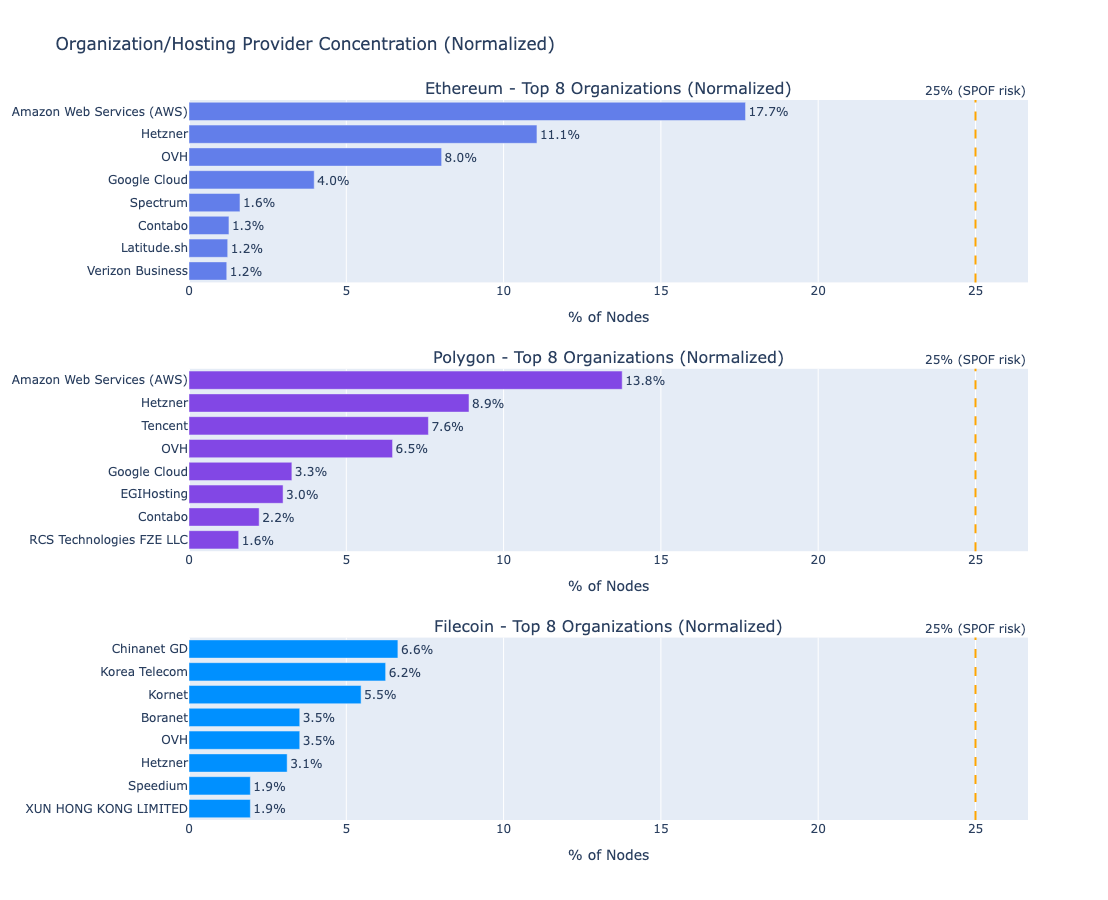

In [26]:
def plot_top_orgs(networks_dict, top_n=10):
    """Create horizontal bar charts showing top organizations for each network."""
    fig = make_subplots(
        rows=len(networks_dict), 
        cols=1,
        subplot_titles=[f"{name.title()} - Top {top_n} Organizations (Normalized)" for name in networks_dict.keys()],
        vertical_spacing=0.12
    )
    
    for idx, (name, df) in enumerate(networks_dict.items(), 1):
        stats = analyze_concentration(df, 'org_normalized', top_n=top_n)
        top_df = stats['top_entries'].copy()
        
        # Truncate long org names
        top_df['org_short'] = top_df['org_normalized'].apply(
            lambda x: x[:40] + '...' if len(x) > 40 else x
        )
        
        # Reverse for top-to-bottom display
        top_df = top_df.iloc[::-1]
        
        fig.add_trace(
            go.Bar(
                y=top_df['org_short'],
                x=top_df['share'],
                orientation='h',
                marker_color=COLORS.get(name, '#666666'),
                text=top_df['share'].apply(lambda x: f'{x:.1f}%'),
                textposition='outside',
                hovertemplate='<b>%{customdata}</b><br>%{x:.1f}%<extra></extra>',
                customdata=top_df['org_normalized'],
                showlegend=False
            ),
            row=idx,
            col=1
        )
        
        # Add threshold line at 25%
        fig.add_vline(x=25, line_dash="dash", line_color="orange", 
                     annotation_text="25% (SPOF risk)", 
                     annotation_position="top",
                     row=idx, col=1)
    
    fig.update_xaxes(title_text="% of Nodes")
    fig.update_layout(
        height=300 * len(networks_dict),
        title_text="Organization/Hosting Provider Concentration (Normalized)",
        showlegend=False
    )
    
    return fig

fig = plot_top_orgs(networks, top_n=8)
fig.show()

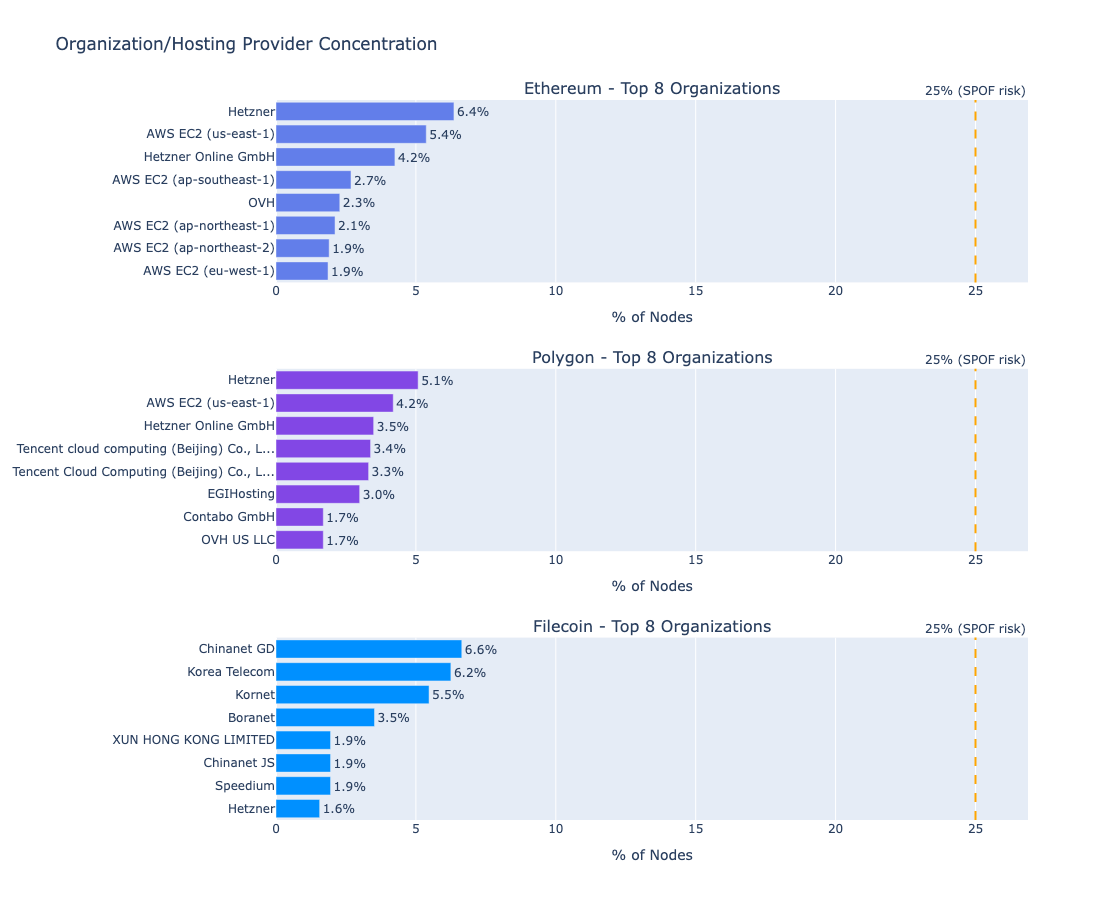

In [27]:
def plot_top_orgs(networks_dict, top_n=10):
    """Create horizontal bar charts showing top organizations for each network."""
    fig = make_subplots(
        rows=len(networks_dict), 
        cols=1,
        subplot_titles=[f"{name.title()} - Top {top_n} Organizations" for name in networks_dict.keys()],
        vertical_spacing=0.12
    )
    
    for idx, (name, df) in enumerate(networks_dict.items(), 1):
        stats = analyze_concentration(df, 'org', top_n=top_n)
        top_df = stats['top_entries'].copy()
        
        # Truncate long org names
        top_df['org_short'] = top_df['org'].apply(
            lambda x: x[:40] + '...' if len(x) > 40 else x
        )
        
        # Reverse for top-to-bottom display
        top_df = top_df.iloc[::-1]
        
        fig.add_trace(
            go.Bar(
                y=top_df['org_short'],
                x=top_df['share'],
                orientation='h',
                marker_color=COLORS.get(name, '#666666'),
                text=top_df['share'].apply(lambda x: f'{x:.1f}%'),
                textposition='outside',
                hovertemplate='<b>%{customdata}</b><br>%{x:.1f}%<extra></extra>',
                customdata=top_df['org'],
                showlegend=False
            ),
            row=idx,
            col=1
        )
        
        # Add threshold line at 25%
        fig.add_vline(x=25, line_dash="dash", line_color="orange", 
                     annotation_text="25% (SPOF risk)", 
                     annotation_position="top",
                     row=idx, col=1)
    
    fig.update_xaxes(title_text="% of Nodes")
    fig.update_layout(
        height=300 * len(networks_dict),
        title_text="Organization/Hosting Provider Concentration",
        showlegend=False
    )
    
    return fig

fig = plot_top_orgs(networks, top_n=8)
fig.show()

## 4. Cumulative Distribution Analysis

How many countries or organizations does it take to control 50% of the network? 67%? This cumulative view reveals concentration dynamics.

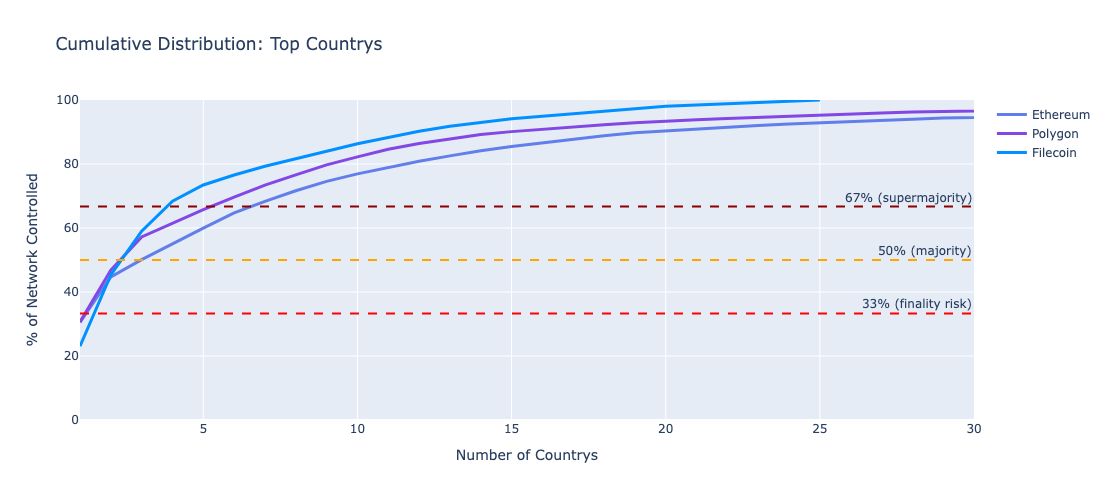

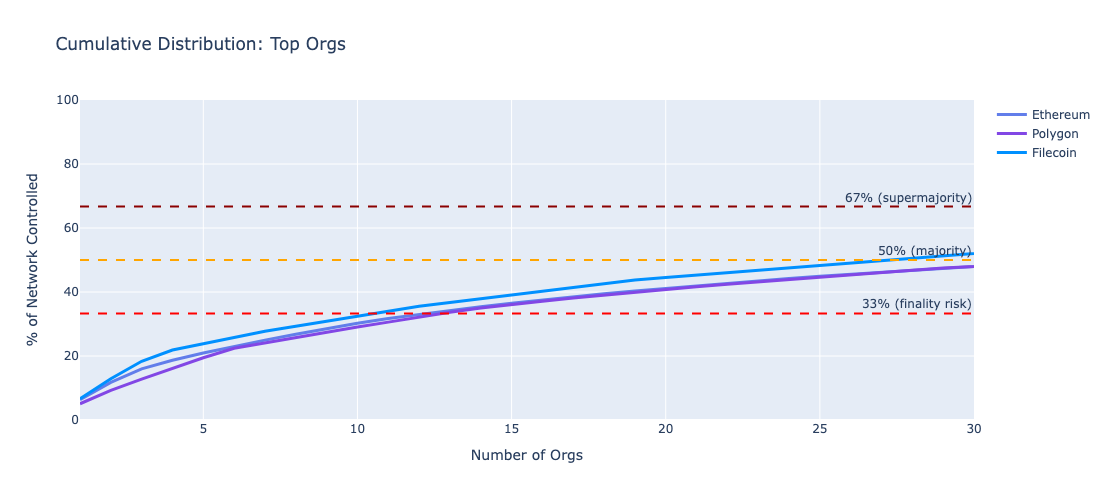

In [28]:
def plot_cumulative_distribution(networks_dict, dimension='country'):
    """Plot cumulative distribution showing top N entities controlling X% of network."""
    fig = go.Figure()
    
    for name, df in networks_dict.items():
        counts = df[dimension].value_counts()
        shares = (counts / len(df) * 100).values
        cumsum = np.cumsum(shares)
        
        fig.add_trace(go.Scatter(
            x=list(range(1, len(cumsum) + 1)),
            y=cumsum,
            mode='lines',
            name=name.title(),
            line=dict(color=COLORS.get(name, '#666666'), width=3),
            hovertemplate='<b>%{fullData.name}</b><br>' +
                         f'Top %{{x}} {dimension}s<br>' +
                         'Control %{y:.1f}% of nodes<extra></extra>'
        ))
    
    # Add threshold lines
    fig.add_hline(y=33.3, line_dash="dash", line_color="red", 
                  annotation_text="33% (finality risk)")
    fig.add_hline(y=50, line_dash="dash", line_color="orange", 
                  annotation_text="50% (majority)")
    fig.add_hline(y=66.7, line_dash="dash", line_color="darkred", 
                  annotation_text="67% (supermajority)")
    
    fig.update_layout(
        title=f"Cumulative Distribution: Top {dimension.title()}s",
        xaxis_title=f"Number of {dimension.title()}s",
        yaxis_title="% of Network Controlled",
        height=500,
        hovermode='x unified',
        xaxis=dict(range=[1, 30]),  # Focus on top 30
        yaxis=dict(range=[0, 100])
    )
    
    return fig

# Country cumulative distribution
fig = plot_cumulative_distribution(networks, 'country')
fig.show()

# Organization cumulative distribution
fig = plot_cumulative_distribution(networks, 'org')
fig.show()

In [29]:
def create_comparison_table(networks_dict): 
    """Create a comparison table showing key metrics across networks.""" 
    comparison_data = []

    for name, df in networks_dict.items():
        country_stats = analyze_concentration(df, 'country')
        org_stats = analyze_concentration(df, 'org_normalized')
        
        comparison_data.append({
            'Network': name.title(),
            'Total Nodes': f"{len(df):,}",
            'Countries': country_stats['num_unique'],
            'Top Country %': f"{country_stats['top_1_share']:.1%}",
            'Top 2 Countries %': f"{country_stats['top_2_share']:.1%}",
            'Country HHI': f"{country_stats['hhi']:.3f}",
            'Organizations': org_stats['num_unique'],
            'Top Org %': f"{org_stats['top_1_share']:.1%}",
            'Top 3 Orgs %': f"{org_stats['top_3_share']:.1%}",
            'Org HHI': f"{org_stats['hhi']:.3f}",
        })
    
    return pd.DataFrame(comparison_data)

comparison_df = create_comparison_table(networks) 
comparison_df

,Network,Total Nodes,Countries,Top Country %,Top 2 Countries %,Country HHI,Organizations,Top Org %,Top 3 Orgs %,Org HHI
0,Ethereum,"17,356",103,30.5%,44.7%,0.129,2184,17.7%,36.8%,0.053
1,Polygon,"11,242",82,30.6%,46.8%,0.142,1252,13.8%,30.3%,0.041
2,Filecoin,256,25,23.0%,45.3%,0.138,108,6.6%,18.4%,0.020


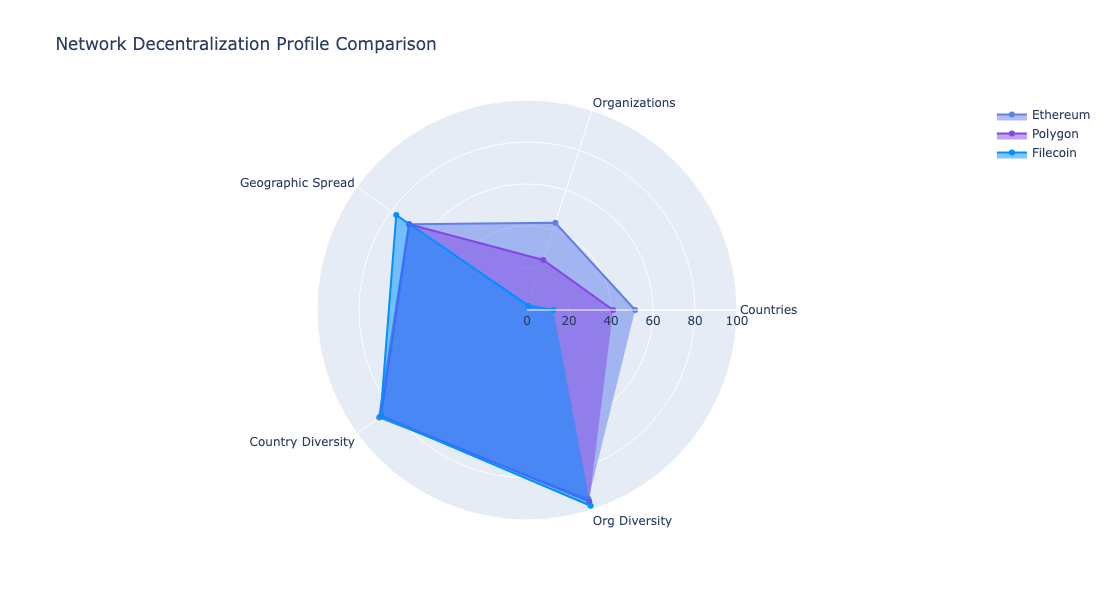

In [30]:
def create_radar_comparison(networks_dict):
    """Create radar chart comparing networks on multiple dimensions."""
    fig = go.Figure()
    
    categories = ['Countries', 'Organizations', 'Geographic Spread', 
                  'Country Diversity', 'Org Diversity']
    
    for name, df in networks_dict.items():
        country_stats = analyze_concentration(df, 'country')
        org_stats = analyze_concentration(df, 'org_normalized')
        
        # Normalize metrics to 0-100 scale
        values = [
            min(100, country_stats['num_unique'] / 2),  # Countries (normalize by /2)
            min(100, org_stats['num_unique'] / 50),      # Orgs (normalize by /50)
            (1 - country_stats['top_1_share']) * 100,    # Geographic spread (inverse of top country)
            (1 - country_stats['hhi']) * 100,            # Country diversity (inverse HHI)
            (1 - org_stats['hhi']) * 100                 # Org diversity (inverse HHI)
        ]
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=name.title(),
            line_color=COLORS.get(name, '#666666')
        ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 100]
            )
        ),
        showlegend=True,
        title="Network Decentralization Profile Comparison",
        height=600
    )
    
    return fig

fig = create_radar_comparison(networks)
fig.show()

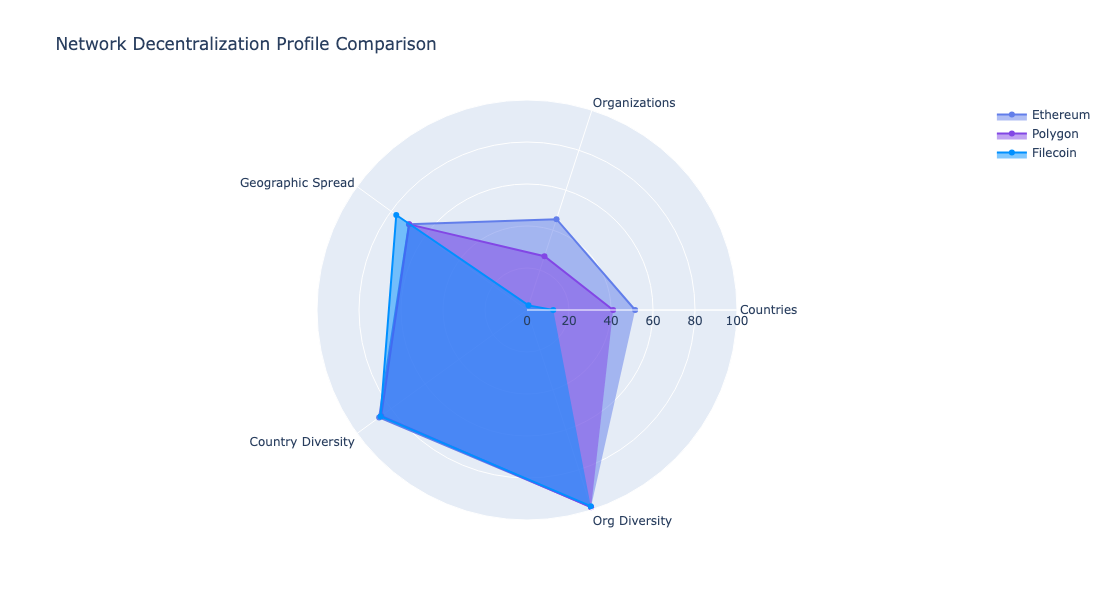

In [31]:
def create_radar_comparison(networks_dict):
    """Create radar chart comparing networks on multiple dimensions."""
    fig = go.Figure()
    
    categories = ['Countries', 'Organizations', 'Geographic Spread', 
                  'Country Diversity', 'Org Diversity']
    
    for name, df in networks_dict.items():
        country_stats = analyze_concentration(df, 'country')
        org_stats = analyze_concentration(df, 'org')
        
        # Normalize metrics to 0-100 scale
        values = [
            min(100, country_stats['num_unique'] / 2),  # Countries (normalize by /2)
            min(100, org_stats['num_unique'] / 50),      # Orgs (normalize by /50)
            (1 - country_stats['top_1_share']) * 100,    # Geographic spread (inverse of top country)
            (1 - country_stats['hhi']) * 100,            # Country diversity (inverse HHI)
            (1 - org_stats['hhi']) * 100                 # Org diversity (inverse HHI)
        ]
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=name.title(),
            line_color=COLORS.get(name, '#666666')
        ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 100]
            )
        ),
        showlegend=True,
        title="Network Decentralization Profile Comparison",
        height=600
    )
    
    return fig

fig = create_radar_comparison(networks)
fig.show()

## 6. GDI Methodology: Step-by-Step Calculation

The **Geographic Decentralization Index (GDI)** synthesizes multiple dimensions into a single score. Here's how it works.

### Three Sub-Indices

1. **PDI (Physical Distribution Index)** - Spatial clustering and geographic spread
   - Uses Moran's I for spatial autocorrelation
   - Effective Number of Locations (ENL) via entropy
   - Spatial HHI across H3 grid cells

2. **JDI (Jurisdictional Diversity Index)** - Country-level distribution
   - Country HHI (concentration measure)
   - Number of distinct countries (absolute diversity)
   - Graduated penalties for top-country concentration

3. **IHI (Infrastructure Heterogeneity Index)** - Provider/organization diversity
   - Organization HHI
   - Number of distinct providers
   - Graduated penalties for top-org concentration

### Composite GDI Formula

```
Step 1: Base average
GDI_base = (PDI + JDI + IHI) / 3

Step 2: Apply hard floors
If any sub-index < 20: cap GDI at 30
Else if any sub-index < 30: cap GDI at 40
Else if any sub-index < 40: cap GDI at 50

GDI = min(GDI_base, floor_cap)
```

**Rationale:** A network's resilience is bounded by its weakest dimension. Strength in two areas cannot compensate for critical vulnerability in the third.

### Interpretation Scale

- **70+**: Well decentralized
- **50-69**: Moderately concentrated
- **35-49**: Concentrated
- **<35**: Highly concentrated

See [docs/METHODOLOGY.md](../../docs/METHODOLOGY.md) for complete details.

In [32]:
# Demonstrate calculation for one network (Ethereum)
# Import production code to show the actual implementation
import sys
sys.path.append('../../src/analysis')
from gdi_standalone import calculate_pdi, calculate_jdi, calculate_ihi, calculate_gdi

print("GDI Calculation Demonstration: Ethereum")
print("=" * 80)

eth_df = networks['ethereum'].dropna(subset=['lat', 'lon', 'country', 'org'])

# Calculate sub-indices
pdi_result = calculate_pdi(eth_df)
jdi_result = calculate_jdi(eth_df)
ihi_result = calculate_ihi(eth_df)

print(f"\n1. Physical Distribution Index (PDI): {pdi_result['pdi']}/100")
print(f"   - Moran's I: {pdi_result['morans_i']:.3f} (clustering measure)")
print(f"   - ENL: {pdi_result['enl']:.1f} effective locations")
print(f"   - Spatial HHI: {pdi_result['spatial_hhi']:.3f}")
print(f"   - Interpretation: {pdi_result['interpretation']}")

print(f"\n2. Jurisdictional Diversity Index (JDI): {jdi_result['jdi']}/100")
print(f"   - Country HHI: {jdi_result['country_hhi']:.3f}")
print(f"   - Countries: {jdi_result['num_countries']}")
print(f"   - Top 3 countries:")
for country, data in list(jdi_result['top_3_countries'].items())[:3]:
    print(f"     • {country}: {data['share']}%")
print(f"   - Interpretation: {jdi_result['interpretation']}")

print(f"\n3. Infrastructure Heterogeneity Index (IHI): {ihi_result['ihi']}/100")
print(f"   - Organization HHI: {ihi_result['org_hhi']:.3f}")
print(f"   - Organizations: {ihi_result['num_orgs']}")
print(f"   - Top 3 orgs:")
for org, data in list(ihi_result['top_3_orgs'].items())[:3]:
    org_short = org[:40] + '...' if len(org) > 40 else org
    print(f"     • {org_short}: {data['share']}%")
print(f"   - Interpretation: {ihi_result['interpretation']}")

# Full GDI calculation
gdi_result = calculate_gdi(eth_df)
print(f"\n{'=' * 80}")
print(f"COMPOSITE GDI: {gdi_result['gdi']}/100 - {gdi_result['interpretation']}")
print(f"{'=' * 80}")

GDI Calculation Demonstration: Ethereum

1. Physical Distribution Index (PDI): 62.5/100
   - Moran's I: 0.250 (clustering measure)
   - ENL: 207.6 effective locations
   - Spatial HHI: 0.021
   - Interpretation: Moderately dispersed

2. Jurisdictional Diversity Index (JDI): 42.9/100
   - Country HHI: 0.143
   - Countries: 95
   - Top 3 countries:
     • United States: 32.4%
     • Germany: 14.9%
     • Finland: 5.7%
   - Interpretation: High concentration

3. Infrastructure Heterogeneity Index (IHI): 55.1/100
   - Organization HHI: 0.016
   - Organizations: 2274
   - Top 3 orgs:
     • Hetzner: 6.9%
     • AWS EC2 (us-east-1): 5.8%
     • Hetzner Online GmbH: 4.6%
   - Interpretation: Moderate concentration

COMPOSITE GDI: 55.8/100 - Weakly decentralized


In [34]:
def calculate_flags(df): 
    """Calculate boolean flags for critical concentration thresholds.""" 
    country_stats = analyze_concentration(df, 'country') 
    org_stats = analyze_concentration(df, 'org_normalized')

    return {
        'single_jurisdiction_dominant': country_stats['top_1_share'] > 0.33,
        'regulatory_capture_risk': country_stats['top_2_share'] > 0.50,
        'infrastructure_spof': org_stats['top_1_share'] > 0.25
    }

In [35]:
# Calculate flags for all networks
print("Critical Concentration Flags")
print("=" * 80)
for name, df in networks.items():
    flags = calculate_flags(df)
    print(f"\n{name.upper()}:")
    print(f"  Single jurisdiction dominant (>33%): {'✗ YES' if flags['single_jurisdiction_dominant'] else '✓ No'}")
    print(f"  Regulatory capture risk (top 2 >50%): {'✗ YES' if flags['regulatory_capture_risk'] else '✓ No'}")
    print(f"  Infrastructure SPOF (top org >25%): {'✗ YES' if flags['infrastructure_spof'] else '✓ No'}")

Critical Concentration Flags

ETHEREUM:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No

POLYGON:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No

FILECOIN:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No


In [36]:
def calculate_flags(df):
    """Calculate boolean flags for critical concentration thresholds."""
    country_stats = analyze_concentration(df, 'country')
    org_stats = analyze_concentration(df, 'org')
    
    return {
        'single_jurisdiction_dominant': country_stats['top_1_share'] > 0.33,
        'regulatory_capture_risk': country_stats['top_2_share'] > 0.50,
        'infrastructure_spof': org_stats['top_1_share'] > 0.25
    }

# Calculate flags for all networks
print("Critical Concentration Flags")
print("=" * 80)
for name, df in networks.items():
    flags = calculate_flags(df)
    print(f"\n{name.upper()}:")
    print(f"  Single jurisdiction dominant (>33%): {'✗ YES' if flags['single_jurisdiction_dominant'] else '✓ No'}")
    print(f"  Regulatory capture risk (top 2 >50%): {'✗ YES' if flags['regulatory_capture_risk'] else '✓ No'}")
    print(f"  Infrastructure SPOF (top org >25%): {'✗ YES' if flags['infrastructure_spof'] else '✓ No'}")

Critical Concentration Flags

ETHEREUM:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No

POLYGON:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No

FILECOIN:
  Single jurisdiction dominant (>33%): ✓ No
  Regulatory capture risk (top 2 >50%): ✓ No
  Infrastructure SPOF (top org >25%): ✓ No


## 8. From Notebook to Production

This notebook demonstrates our methodology interactively. We've productionized this analysis into scripts that generate the live dashboard data.

### Production Scripts

- **[`src/analysis/gdi_standalone.py`](../../src/analysis/gdi_standalone.py)** - Main GDI calculation engine implementing the PDI, JDI, and IHI formulas demonstrated in this notebook
- **[`src/analysis/models.py`](../../src/analysis/models.py)** - Data models and types

### Output Format

The production scripts generate `data/gdi_results.json`, which powers the interactive dashboard at [geobeat.xyz](https://geobeat.xyz).

### Reproducibility

To regenerate the dashboard data:
```bash
cd src/analysis
python gdi_standalone.py
```

The output will be saved to:
- `data/gdi_results.json` (consumed by frontend)
- `src/frontend/geobeat-ui/lib/data/gdi_results.json` (copied for Next.js import)

### Code Bridge Example

Here's how the notebook analysis maps to production code:

**Notebook (exploratory):**
```python
# Calculate country HHI
country_counts = df['country'].value_counts()
shares = country_counts / len(df)
hhi = (shares ** 2).sum()
```

**Production (gdi_standalone.py:163-176):**
```python
def calculate_jdi(df: pd.DataFrame) -> Dict:
    country_counts = df["country"].value_counts()
    total_nodes = len(df)
    shares = country_counts / total_nodes
    country_hhi = (shares**2).sum()
    # ... additional logic ...
```

This ensures the methodology you see here is exactly what runs in production.

In [37]:
# Demonstrate loading the production output
import json

try:
    with open('../gdi_results.json', 'r') as f:
        production_results = json.load(f)
    
    print("Production GDI Results (from gdi_results.json):")
    print("=" * 80)
    for network in production_results:
        print(f"\n{network['name']} ({network['symbol']}):")
        print(f"  GDI: {network.get('gdi', 'N/A')}/100")
        print(f"  PDI: {network.get('pdi', 'N/A')}/100")
        print(f"  JDI: {network.get('jdi', 'N/A')}/100")
        print(f"  IHI: {network.get('ihi', 'N/A')}/100")
        print(f"  Node Count: {network.get('nodeCount', 'N/A'):,}")
except FileNotFoundError:
    print("gdi_results.json not found. Run 'python src/analysis/gdi_standalone.py' to generate it.")

Production GDI Results (from gdi_results.json):

Ethereum (ETH):
  GDI: N/A/100
  PDI: 62.5/100
  JDI: 42.9/100
  IHI: 55.1/100
  Node Count: 16,086

Polygon (MATIC):
  GDI: N/A/100
  PDI: 59.3/100
  JDI: 42.7/100
  IHI: 54.8/100
  Node Count: 9,688

Filecoin (FIL):
  GDI: N/A/100
  PDI: 58.2/100
  JDI: 40.8/100
  IHI: 40.4/100
  Node Count: 223


## Conclusion

This notebook has shown:

1. **Data transparency** - Raw CSV files → enriched metadata → analysis
2. **Concentration patterns** - Visual and quantitative evidence of geographic clustering
3. **Methodology demonstration** - Step-by-step GDI calculation
4. **Production bridge** - How exploratory analysis becomes live code

### Key Findings

- All three networks show significant geographic concentration
- Top 2-3 countries control >50% of nodes in most networks
- Cloud hosting concentration creates infrastructure dependencies
- Current GDI scores reflect these concentration risks

### Next Steps

To learn more:
- Read the full [Methodology](../../docs/METHODOLOGY.md)
- Explore the [production code](../../src/analysis/)
- Visit the [live dashboard](https://geobeat.xyz)
- Join the discussion on [GitHub](https://github.com/DecentralizedGeo/GEOBEAT)

---

*This notebook is part of the GEOBEAT project. For questions or contributions, see our [Contributing Guide](../../CONTRIBUTING.md).*